In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shrutibhargava94/india-air-quality-data/data.csv


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

In [19]:
r=102303608

a_r=0.5*(r%7)
b_r=0.3*((r%5)+1)

print("a_r=",a_r)
print("b_r=",b_r)

a_r= 0.5
b_r= 1.2


In [20]:
data=pd.read_csv(
    "/kaggle/input/datasets/shrutibhargava94/india-air-quality-data/data.csv",
    encoding="latin1",
    low_memory=False
)

print("Dataset Loaded Successfully")
print("Columns are:",data.columns)

x=data["no2"].dropna().values

x=(x-np.mean(x))/np.std(x)

print("Total samples:",len(x))

Dataset Loaded Successfully
Columns are: Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')
Total samples: 419509


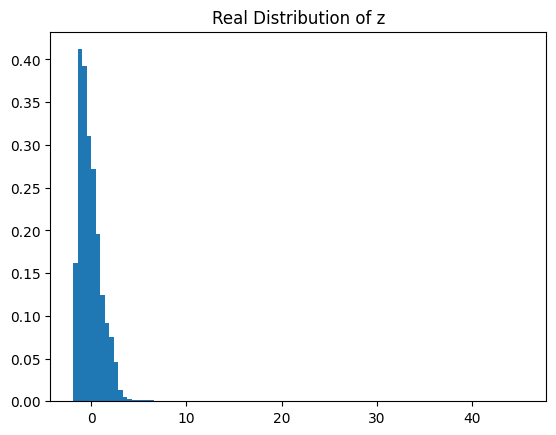

In [21]:
def transform(x,a_r,b_r):
    return x+a_r*np.sin(b_r*x)

z=transform(x,a_r,b_r)

plt.hist(z,bins=100,density=True)
plt.title("Real Distribution of z")
plt.show()

In [22]:
z=z.reshape(-1,1)
z_tensor=torch.tensor(z,dtype=torch.float32)

In [23]:
noise_dim=5

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(noise_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self,z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(1,64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.model(x)

G=Generator()
D=Discriminator()

In [24]:
criterion=nn.BCELoss()

g_optimizer=optim.Adam(G.parameters(),lr=0.0005)
d_optimizer=optim.Adam(D.parameters(),lr=0.0005)

epochs=2000
batch_size=128

In [25]:
for epoch in range(epochs):

    idx=np.random.randint(0,len(z),batch_size)
    real_samples=z_tensor[idx]

    real_labels=torch.ones(batch_size,1)
    fake_labels=torch.zeros(batch_size,1)

    noise=torch.randn(batch_size,noise_dim)
    fake_samples=G(noise).detach()

    d_real=D(real_samples)
    d_fake=D(fake_samples)

    d_loss_real=criterion(d_real,real_labels)
    d_loss_fake=criterion(d_fake,fake_labels)
    d_loss=d_loss_real+d_loss_fake

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    noise=torch.randn(batch_size,noise_dim)
    fake_samples=G(noise)

    g_loss=criterion(D(fake_samples),real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch%200==0:
        print(f"Epoch{epoch}|D Loss:{d_loss.item():.4f}|G Loss:{g_loss.item():.4f}")

Epoch0|D Loss:1.4015|G Loss:0.6968
Epoch200|D Loss:1.4563|G Loss:0.9141
Epoch400|D Loss:0.9089|G Loss:1.1802
Epoch600|D Loss:1.3962|G Loss:0.6375
Epoch800|D Loss:1.3988|G Loss:0.6922
Epoch1000|D Loss:1.3864|G Loss:0.7009
Epoch1200|D Loss:1.3940|G Loss:0.6903
Epoch1400|D Loss:1.3778|G Loss:0.6890
Epoch1600|D Loss:1.3923|G Loss:0.6980
Epoch1800|D Loss:1.3847|G Loss:0.6869


In [26]:
noise=torch.randn(10000,noise_dim)
generated_samples=G(noise).detach().numpy()

In [27]:
kde=KernelDensity(kernel='gaussian',bandwidth=0.2)
kde.fit(generated_samples)

x_vals=np.linspace(generated_samples.min(),
                   generated_samples.max(),
                   1000).reshape(-1,1)

log_density=kde.score_samples(x_vals)
pdf_estimated=np.exp(log_density)

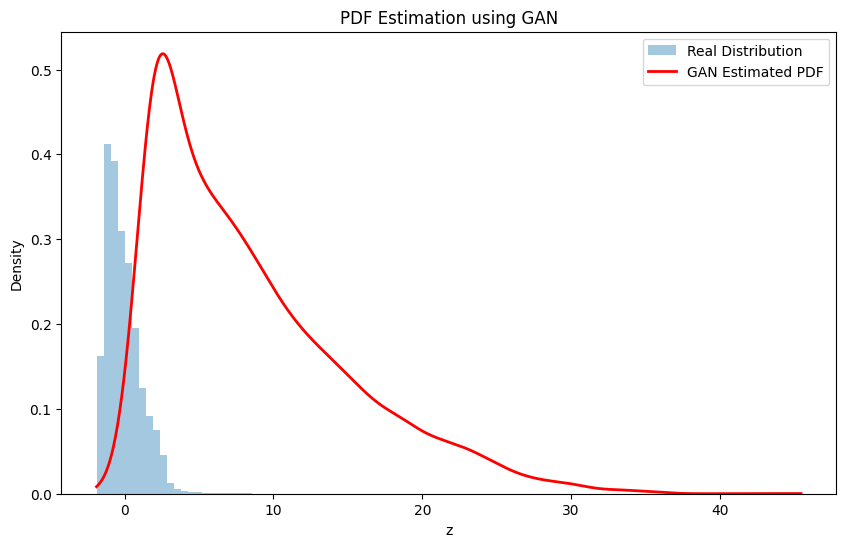

In [35]:
plt.figure(figsize=(10,6))

plt.hist(z,bins=100,density=True,alpha=0.4,label="Real Distribution")
plt.plot(x_vals,pdf_estimated,color='red',linewidth=2,label="GAN Estimated PDF")

plt.title("PDF Estimation using GAN")
plt.xlabel("z")
plt.ylabel("Density")
plt.legend()
plt.show()

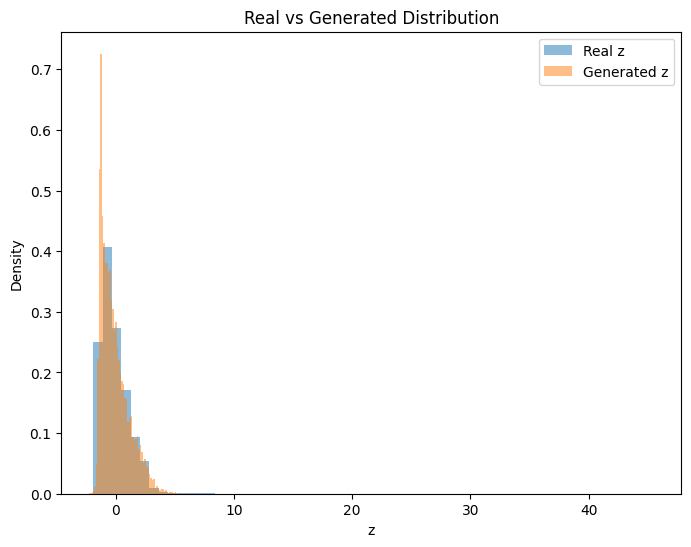

In [33]:
plt.figure(figsize=(8,6))

plt.hist(z.flatten(),bins=60,density=True,alpha=0.5,label="Real z")
plt.hist(generated.flatten(),bins=60,density=True,alpha=0.5,label="Generated z")

plt.legend()
plt.title("Real vs Generated Distribution")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

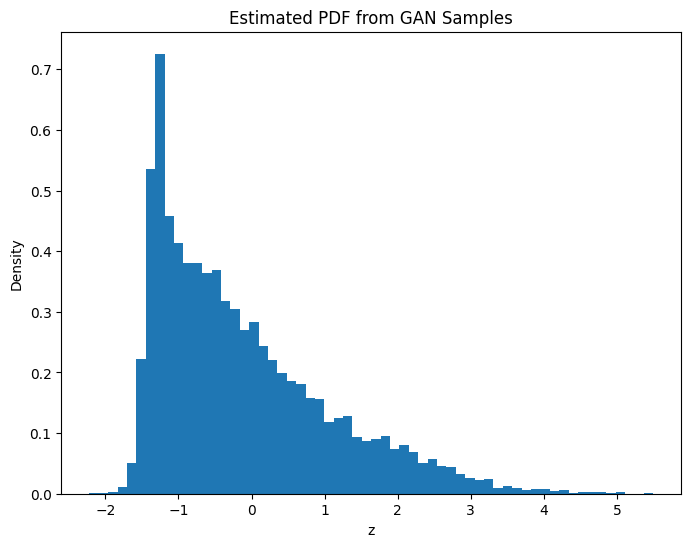

In [34]:
plt.figure(figsize=(8,6))

plt.hist(generated.flatten(),bins=60,density=True)

plt.title("Estimated PDF from GAN Samples")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()